Number of commodities: 72
Number of dates: 132


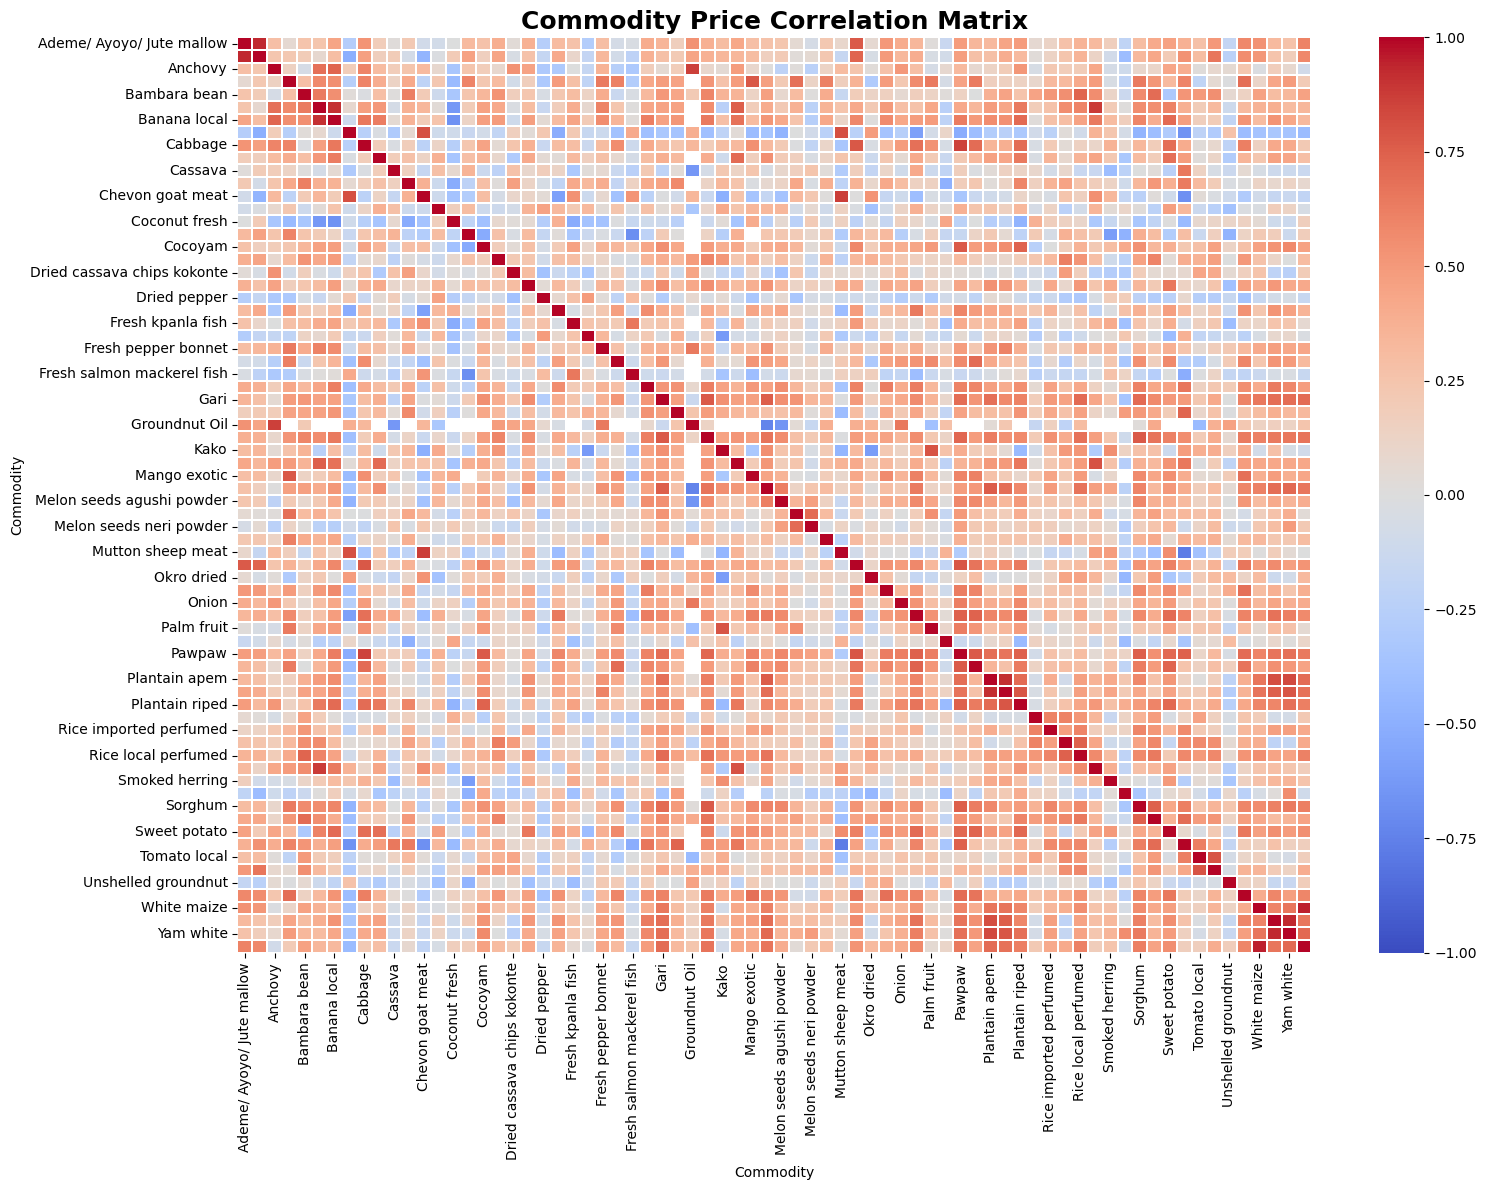


TOP 5 MOST POSITIVELY CORRELATED COMMODITY PAIRS
              Commodity 1       Commodity 2 Correlation
              White maize      Yellow maize       0.949
                 Yam puna         Yam white       0.934
Ademe/ Ayoyo/ Jute mallow Alefu/ Amaranthus       0.934
            Plantain apem   Plantain apentu       0.920
            Banana exotic      Banana local       0.907


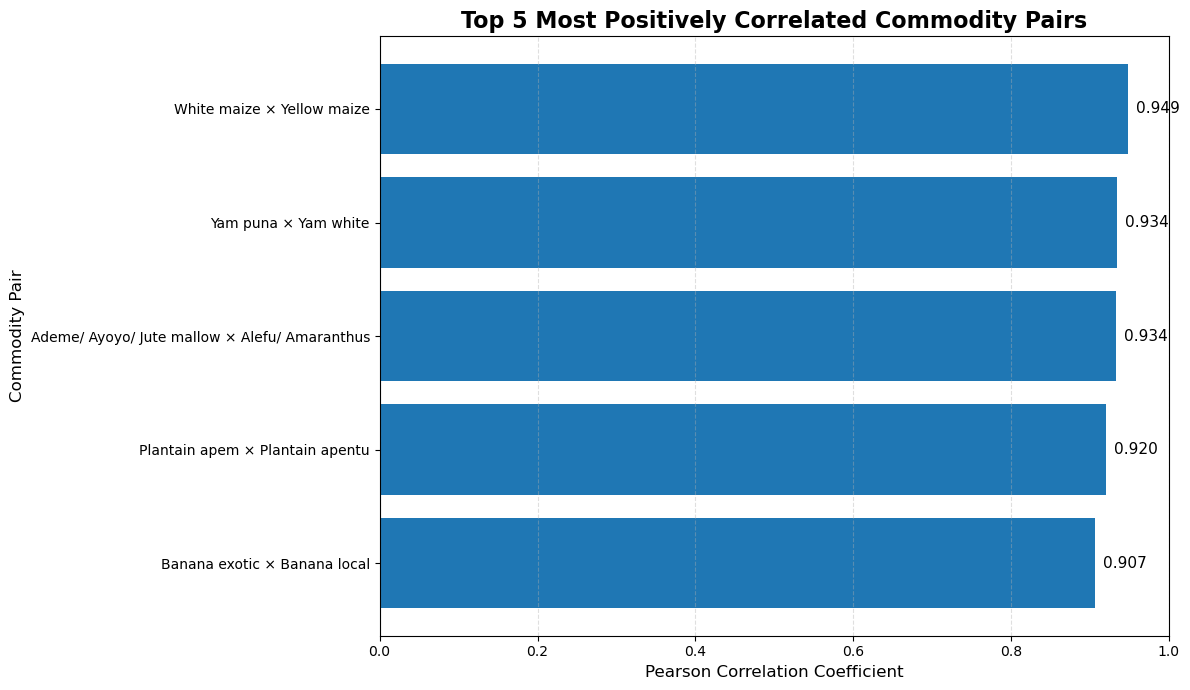

In [4]:
# ============================================
# TOP 5 CORRELATED COMMODITIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------
# 1. LOAD DATA
# --------------------------------------------

file_path = (r"C:\Users\T H I N K P A D\Downloads\Commodity prices _(Cleaned).csv")

df = pd.read_csv(file_path)

# --------------------------------------------
# 2. CLEAN DATA
# --------------------------------------------

# Your dataset uses DD/MM/YYYY
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)

df = df.dropna(
    subset=["Date", "Commodity", "Price"]
)

# --------------------------------------------
# 3. AVERAGE PRICE BY DATE AND COMMODITY
# --------------------------------------------

daily_prices = (
    df.groupby(
        ["Date", "Commodity"],
        as_index=False
    )["Price"]
    .mean()
)

# Convert to wide format
daily_prices = daily_prices.pivot(
    index="Date",
    columns="Commodity",
    values="Price"
)

# --------------------------------------------
# 4. REMOVE COMMODITIES WITH TOO FEW OBSERVATIONS
# --------------------------------------------

# Keep commodities with at least 10 observations
daily_prices = daily_prices.dropna(
    axis=1,
    thresh=10
)

print("Number of commodities:", daily_prices.shape[1])
print("Number of dates:", daily_prices.shape[0])

# --------------------------------------------
# 5. CORRELATION MATRIX
# --------------------------------------------

corr_matrix = daily_prices.corr(
    method="pearson",
    min_periods=10
)

# --------------------------------------------
# 6. HEATMAP
# --------------------------------------------

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3
)

plt.title(
    "Commodity Price Correlation Matrix",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Commodity")
plt.ylabel("Commodity")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# --------------------------------------------
# 7. EXTRACT CORRELATION PAIRS
# --------------------------------------------

# Convert correlation matrix into a NumPy array
corr_values = corr_matrix.values

# Get upper triangle indices
row_indices, col_indices = np.triu_indices(
    corr_values.shape[0],
    k=1
)

# Create the pairs manually
correlation_pairs = pd.DataFrame({
    "Commodity 1": corr_matrix.index[row_indices],
    "Commodity 2": corr_matrix.columns[col_indices],
    "Correlation": corr_values[
        row_indices,
        col_indices
    ]
})

# Remove missing correlations
correlation_pairs = correlation_pairs.dropna(
    subset=["Correlation"]
)

# --------------------------------------------
# 8. FIND TOP 5 POSITIVE CORRELATIONS
# --------------------------------------------

top_5 = (
    correlation_pairs
    .sort_values(
        by="Correlation",
        ascending=False
    )
    .head(5)
    .reset_index(drop=True)
)

# --------------------------------------------
# 9. PRINT TOP 5
# --------------------------------------------

print("\n" + "=" * 70)
print("TOP 5 MOST POSITIVELY CORRELATED COMMODITY PAIRS")
print("=" * 70)

print(
    top_5.to_string(
        index=False,
        formatters={
            "Correlation": "{:.3f}".format
        }
    )
)

# --------------------------------------------
# 10. CREATE LABELS
# --------------------------------------------

top_5["Pair"] = (
    top_5["Commodity 1"]
    + " × "
    + top_5["Commodity 2"]
)

# --------------------------------------------
# 11. TOP 5 BAR CHART
# --------------------------------------------

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top_5["Pair"],
    top_5["Correlation"]
)

# Highest correlation at the top
plt.gca().invert_yaxis()

# Add correlation values
for bar, value in zip(
    bars,
    top_5["Correlation"]
):
    plt.text(
        value + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=11
    )

plt.xlabel(
    "Pearson Correlation Coefficient",
    fontsize=12
)

plt.ylabel(
    "Commodity Pair",
    fontsize=12
)

plt.title(
    "Top 5 Most Positively Correlated Commodity Pairs",
    fontsize=16,
    fontweight="bold"
)

plt.xlim(0, 1)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()